<h1><font color='blue'> 8E and 8F: Finding the Probability P(Y==1|X)</font></h1>

<h2><font color='Geen'> 8E: Implementing Decision Function of SVM RBF Kernel</font></h2>

<font face=' Comic Sans MS' size=3>After we train a kernel SVM model, we will be getting support vectors and their corresponsing coefficients $\alpha_{i}$

Check the documentation for better understanding of these attributes: 

https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
<img src='https://i.imgur.com/K11msU4.png' width=500>

As a part of this assignment you will be implementing the ```decision_function()``` of kernel SVM, here decision_function() means based on the value return by ```decision_function()``` model will classify the data point either as positive or negative

Ex 1: In logistic regression After traning the models with the optimal weights $w$ we get, we will find the value $\frac{1}{1+\exp(-(wx+b))}$, if this value comes out to be < 0.5 we will mark it as negative class, else its positive class

Ex 2: In Linear SVM After traning the models with the optimal weights $w$ we get, we will find the value of $sign(wx+b)$, if this value comes out to be -ve we will mark it as negative class, else its positive class.

Similarly in Kernel SVM After traning the models with the coefficients $\alpha_{i}$ we get, we will find the value of 
$sign(\sum_{i=1}^{n}(y_{i}\alpha_{i}K(x_{i},x_{q})) + intercept)$, here $K(x_{i},x_{q})$ is the RBF kernel. If this value comes out to be -ve we will mark $x_{q}$ as negative class, else its positive class.

RBF kernel is defined as: $K(x_{i},x_{q})$ = $exp(-\gamma ||x_{i} - x_{q}||^2)$

For better understanding check this link: https://scikit-learn.org/stable/modules/svm.html#svm-mathematical-formulation
</font>

## Task E

> 1. Split the data into $X_{train}$(60), $X_{cv}$(20), $X_{test}$(20)

> 2. Train $SVC(gamma=0.001, C=100.)$ on the ($X_{train}$, $y_{train}$)

> 3. Get the decision boundry values $f_{cv}$ on the $X_{cv}$ data  i.e. ` `$f_{cv}$ ```= decision_function(```$X_{cv}$```)```  <font color='red'>you need to implement this decision_function()</font>

# Finding the decision value manually  

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import numpy as np
from sklearn.svm import SVC

In [2]:
X, y = make_classification(n_samples=5000, n_features=5, n_redundant=2,
                           n_classes=2, weights=[0.7], class_sep=0.7, random_state=15)

In [3]:
X_train = X[0:3000]
X_cv = X[3000:4000]
X_test = X[4000:5000]
y_train = y[0:3000]
y_cv = y[3000:4000]
y_test = y[4000:5000]
print(X_cv.shape)

(1000, 5)


In [5]:
clf = SVC(gamma=0.001, C=100,kernel='rbf')
clf.fit(X_train,y_train)
df_by_sk_learn = clf.decision_function(X_cv)
print(df_by_sk_learn[0])

0.9190135676894946


In [6]:
import math
def decision_function(X_cv):
    d_value= []
    for x in X_cv:
        num = 0
        for sv,a in zip(clf.support_vectors_,clf.dual_coef_[0]):
            distance = abs((sv-x)*(sv-x))
            distance_dot = np.dot(sv-x,sv-x)
            #print(distance,"distance")
            #print(distance_dot,"distance_dot")
            num+=a*(math.exp(-0.001*np.linalg.norm(distance_dot)))
        num+=clf.intercept_
        d_value.append(num[0])
    return d_value   

In [9]:

df_by_manually = decision_function(X_cv)


In [12]:
print(df_by_manually[0:5],"decison function manually")
print(df_by_sk_learn[0:5],"decison function using sk-learn")

[0.9190135676894946, 1.6615868465800978, -2.077669996985714, -2.5742985387863038, -2.508037245067323] decison function manually
[ 0.91901357  1.66158685 -2.07767    -2.57429854 -2.50803725] decison function using sk-learn


# Observation

decision function value of the both (using sklearn and using manual functiion) has been checked and verified and it has been matched for both the cases
the first 5 value for both the functionality has given below

[0.9190135676894946, 1.6615868465800978, -2.077669996985714, -2.5742985387863038, -2.508037245067323] decison function manually


[ 0.91901357  1.66158685 -2.07767    -2.57429854 -2.50803725] decison function using sk-learn

### Pseudo code

clf = SVC(gamma=0.001, C=100.)<br>
clf.fit(Xtrain, ytrain)

<font color='green'>def</font> <font color='blue'>decision_function</font>(Xcv, ...): #use appropriate parameters <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<font color='green'>for</font> a data point $x_q$ <font color='green'>in</font> Xcv: <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<font color='grey'>#write code to implement $(\sum_{i=1}^{\text{all the support vectors}}(y_{i}\alpha_{i}K(x_{i},x_{q})) + intercept)$, here the values $y_i$, $\alpha_{i}$, and $intercept$ can be obtained from the trained model</font><br>
   <font color='green'>return</font> <font color='grey'><i># the decision_function output for all the data points in the Xcv</i></font>
    
fcv = decision_function(Xcv, ...)  <i># based on your requirement you can pass any other parameters </i>

<b>Note</b>: Make sure the values you get as fcv, should be equal to outputs of clf.decision_function(Xcv)


# 8F: Implementing Platt Scaling to find P(Y==1|X)

In [28]:
N_plus = list(y_cv).count(1)
N_minus = list(y_cv).count(0)
y_plus = ((N_plus + 1)/(N_plus + 2))
y_minus = 1/(N_minus + 2)
print(y_plus,N_plus)
print(y_minus,N_minus)
y_cv_updated = []
for index,value in enumerate(y_cv):
    if value ==1:
        y_cv_updated.append(y_plus)
    else:
        y_cv_updated.append(y_minus)       
    

0.9967532467532467 306
0.0014367816091954023 694


In [29]:
y_CV = np.array(y_cv_updated)

In [30]:
def initialize_weights(dim):
    ''' In this function, we will initialize our weights and bias'''
    #initialize the weights to zeros array of (dim,1) dimensions
    #you use zeros_like function to initialize zero, check this link https://docs.scipy.org/doc/numpy/reference/generated/numpy.zeros_like.html
    #initialize bias to zero
    w = np.zeros(dim)
    b =0
    #print(w,"val")
    return w,b


w,b = initialize_weights(1)

In [31]:
def sigmoid(w,x,b):
    ''' In this function, we will return sigmoid of z'''
    w= w.T
    sig_term = np.dot(w,x) + b
    sig_value = 1/(1 + np.exp(-sig_term))
    # compute sigmoid(z) and return

    return sig_value

In [32]:
def log_loss(w,b,X,Y):
    sum_log = 0
    N = len(X)
    for i in range(N):
        sum_log+=Y[i]*np.log10(sigmoid(w,X[i],b)) + (1-Y[i])*np.log10(1-sigmoid(w,X[i],b))
    return -1*sum_log/N

In [33]:
import random
def gradient_dw(x,y,w,b,alpha,N):
    '''In this function, we will compute the gardient w.r.to w '''
    w= w.T
    sig_term = np.dot(w,x) + b
    sig_value = 1/(1 + np.exp(-sig_term)) 
    dw = x*(y-sig_value - (alpha/N)*w)
    #print(dw)
    return dw

In [34]:
def gradient_db(x,y,w,b):  
    w = w.T
    sig_term = np.dot(w,x) + b
    sig_val = 1/(1 + np.exp(-sig_term))
    db = y - sig_val
    return db

In [43]:
def train(X_train,y_train,epochs,alpha,eta0):
    ''' In this function, we will implement logistic regression'''
    #Here eta0 is learning rate
    #implement the code as follows
    # initalize the weights (call the initialize_weights(X_train[0]) function)
    W,B =initialize_weights(1) 
    log_loss_list=[]
    # for every epoch
    for i in range(epochs):
      print(i,"epochs")
      for index,value in enumerate(X_train):
          
          grad_w= gradient_dw(X_train[index],y_train[index],W,B,alpha,1)
          grad_b= gradient_db(X_train[index],y_train[index],W,B)  
          
          W = W  + (eta0*grad_w)
          B = B + (eta0*grad_b)
      logloss = log_loss(W,B,X_train,y_train)
      print(logloss[0])
      log_loss_list.append(logloss[0])  
    return W,B ,log_loss_list      

In [44]:
eta0=0.0001
alpha=0.0001
N=1000
epochs=20
#w,b,loss_train_list,loss_test_list = train(manual_d_val,y_CV,epochs,alpha,eta0)
W,B,log_loss_list = train(df_by_manually,y_CV,epochs,alpha,eta0)


0 epochs
0.26205535960935544
1 epochs
0.23308564247030236
2 epochs
0.21119304717560505
3 epochs
0.19430743302198786
4 epochs
0.1810103568913822
5 epochs
0.17033331596857493
6 epochs
0.16160810771562817
7 epochs
0.15436597545366035
8 epochs
0.14827180602217552
9 epochs
0.1430814055862927
10 epochs
0.13861353571628973
11 epochs
0.13473135166801442
12 epochs
0.13132987574776755
13 epochs
0.128327395890161
14 epochs
0.12565945742904935
15 epochs
0.12327459651634443
16 epochs
0.12113126266404928
17 epochs
0.11919556622855298
18 epochs
0.11743960698025999
19 epochs
0.1158402179342514


In [45]:
print(log_loss_list)

[0.26205535960935544, 0.23308564247030236, 0.21119304717560505, 0.19430743302198786, 0.1810103568913822, 0.17033331596857493, 0.16160810771562817, 0.15436597545366035, 0.14827180602217552, 0.1430814055862927, 0.13861353571628973, 0.13473135166801442, 0.13132987574776755, 0.128327395890161, 0.12565945742904935, 0.12327459651634443, 0.12113126266404928, 0.11919556622855298, 0.11743960698025999, 0.1158402179342514]


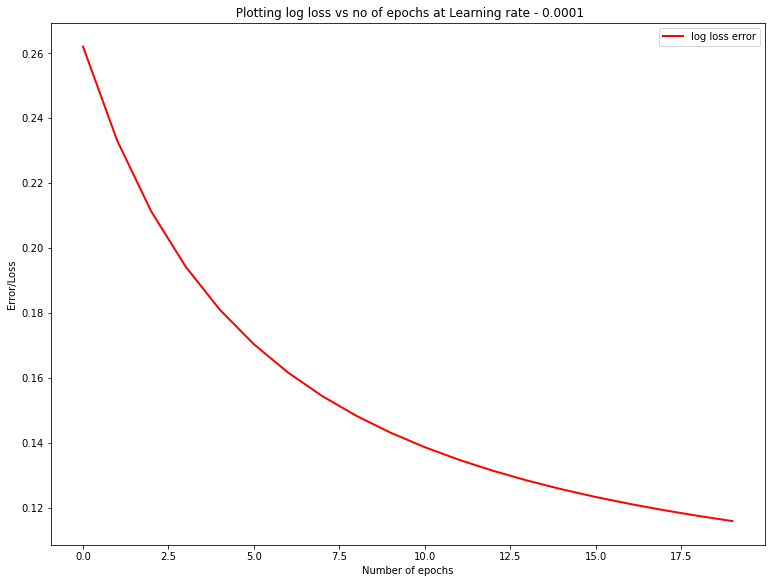

In [48]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12.8, 9.6))
plt.plot(range(len(log_loss_list)), log_loss_list, color='red', lw=2, label='log loss error')
plt.xlabel('Number of epochs')
plt.ylabel('Error/Loss')
plt.legend(loc="upper right")
plt.title(" Plotting log loss vs no of epochs at Learning rate - " + str(alpha))
plt.show()

In [27]:
print(W,B)

(1,) [-0.0977231]


In [20]:
manual_test = decision_function(X_test)

In [26]:
calibration_value = []
for index,value in enumerate(X_test):
    sig_term = np.dot(W,manual_test[index]) + B
    sig_value = 1/(1 + np.exp(-sig_term)) 
    calibration_value.append(sig_value[0])
print(calibration_value)

[0.3791370650280042, 0.12132676726008759, 0.023130306069338802, 0.6116506189527559, 0.7607907892221427, 0.5367381547637804, 0.1385699252347544, 0.07050402767244052, 0.048702851407247436, 0.14295094104796777, 0.019254315133033453, 0.766979940177075, 0.02813124413512894, 0.22242558000861892, 0.7658777126396585, 0.09047809807387906, 0.6316020568600177, 0.10705260121397701, 0.6370140829986348, 0.5173746381502788, 0.35111581982166146, 0.5719994170711612, 0.7214365431901218, 0.38114874674984395, 0.056845270682779836, 0.39004752974240725, 0.10929081717661858, 0.08316687936430703, 0.051875904034928776, 0.08859284054357207, 0.22765527369854405, 0.11557009812435998, 0.846101609859097, 0.7389933429710944, 0.7250950930008401, 0.0762397394932194, 0.10554914875167329, 0.7177015840357972, 0.24739254993225585, 0.08153151508379623, 0.21275105862912655, 0.08064640603656704, 0.0809774349969594, 0.07395364943630148, 0.7969572397876645, 0.7594393423739789, 0.4159543389326031, 0.648194287784771, 0.058815724

<h2><font color='Geen'> 8F: Implementing Platt Scaling to find P(Y==1|X)</font></h2>

Check this <a href='https://drive.google.com/open?id=133odBinMOIVb_rh_GQxxsyMRyW-Zts7a'>PDF</a>
<img src='https://i.imgur.com/CAMnVnh.png'>


## TASK F


> 4. Apply SGD algorithm with ($f_{cv}$, $y_{cv}$) and find the weight $W$ intercept $b$ ```Note: here our data is of one dimensional so we will have a one dimensional weight vector i.e W.shape (1,)``` 

> Note1: Don't forget to change the values of $y_{cv}$ as mentioned in the above image. you will calculate y+, y- based on data points in train data

> Note2: the Sklearn's SGD algorithm doesn't support the real valued outputs, you need to use the code that was done in the `'Logistic Regression with SGD and L2'` Assignment after modifying loss function, and use same parameters that used in that assignment.
<img src='https://i.imgur.com/zKYE9Oc.png'>
if Y[i] is 1, it will be replaced with y+ value else it will replaced with y- value

> 5. For a given data point from $X_{test}$, $P(Y=1|X) = \frac{1}{1+exp(-(W*f_{test}+ b))}$ where ` `$f_{test}$ ```= decision_function(```$X_{test}$```)```, W and b will be learned as metioned in the above step

__Note: in the above algorithm, the steps 2, 4 might need hyper parameter tuning, To reduce the complexity of the assignment we are excluding the hyerparameter tuning part, but intrested students can try that__


If any one wants to try other calibration algorithm istonic regression also please check these tutorials

1. http://fa.bianp.net/blog/tag/scikit-learn.html#fn:1

2. https://drive.google.com/open?id=1MzmA7QaP58RDzocB0RBmRiWfl7Co_VJ7

3. https://drive.google.com/open?id=133odBinMOIVb_rh_GQxxsyMRyW-Zts7a

4. https://stat.fandom.com/wiki/Isotonic_regression#Pool_Adjacent_Violators_Algorithm
